In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib

## Read in data

In [2]:
df = pd.read_csv('../data/part_a/part_a_results.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.head()

(57000, 9)


,puzzle_id,strategy,size,word_count,avg_word_length,cells_examined,execution_time,words_found,total_words
0,A_10x10_0000,Brute Force,10,5,6.4,234,0.000049,5,5
1,A_10x10_0000,Ordered Search,10,5,6.4,234,0.000071,5,5
2,A_10x10_0000,Uncommon Letter Search,10,5,6.4,234,0.000042,5,5
3,A_10x10_0000,Random Sample (attempts=5000),10,5,6.4,310,0.000200,5,5
4,A_10x10_0000,Patch Search,10,5,6.4,1214,0.000303,5,5


In [3]:
df.describe()

,size,word_count,avg_word_length,cells_examined,execution_time,words_found,total_words
count,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000
mean,55.000000,35.543263,6.443132,127471.021386,0.018037,35.543263,35.543263
std,27.386368,18.627199,0.222990,137774.447149,0.019057,18.627199,18.627199
min,10.000000,5.000000,5.000000,51.000000,0.000020,5.000000,5.000000
25%,30.000000,20.000000,6.314286,13360.750000,0.002342,20.000000,20.000000
50%,55.000000,35.000000,6.444444,71793.000000,0.010527,35.000000,35.000000
75%,80.000000,50.000000,6.571429,210210.500000,0.029255,50.000000,50.000000
max,100.000000,80.000000,7.800000,639018.000000,0.171251,80.000000,80.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   puzzle_id        57000 non-null  object 
 1   strategy         57000 non-null  object 
 2   size             57000 non-null  int64  
 3   word_count       57000 non-null  int64  
 4   avg_word_length  57000 non-null  float64
 5   cells_examined   57000 non-null  int64  
 6   execution_time   57000 non-null  float64
 7   words_found      57000 non-null  int64  
 8   total_words      57000 non-null  int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 3.9+ MB


# Time analysis

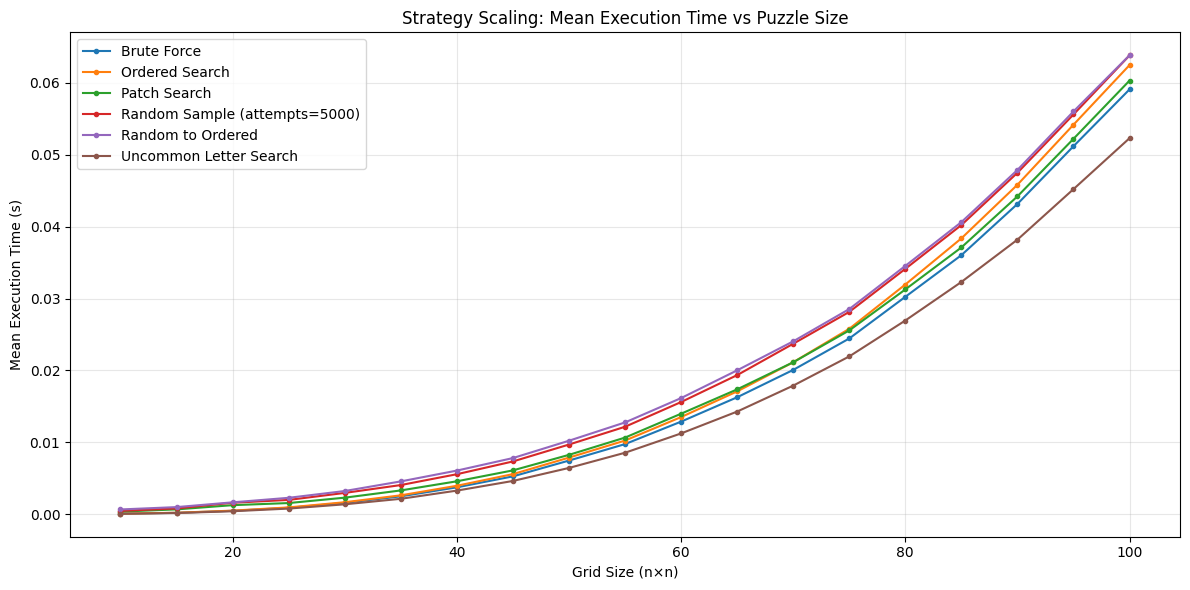

In [5]:
mean_time = df.groupby(['strategy', 'size'])['execution_time'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

for strategy, group in mean_time.groupby('strategy'):
    ax.plot(group['size'], group['execution_time'], marker='o', markersize=3, label=strategy)

ax.set_xlabel('Grid Size (n×n)')
ax.set_ylabel('Mean Execution Time (s)')
ax.set_title('Strategy Scaling: Mean Execution Time vs Puzzle Size')


ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

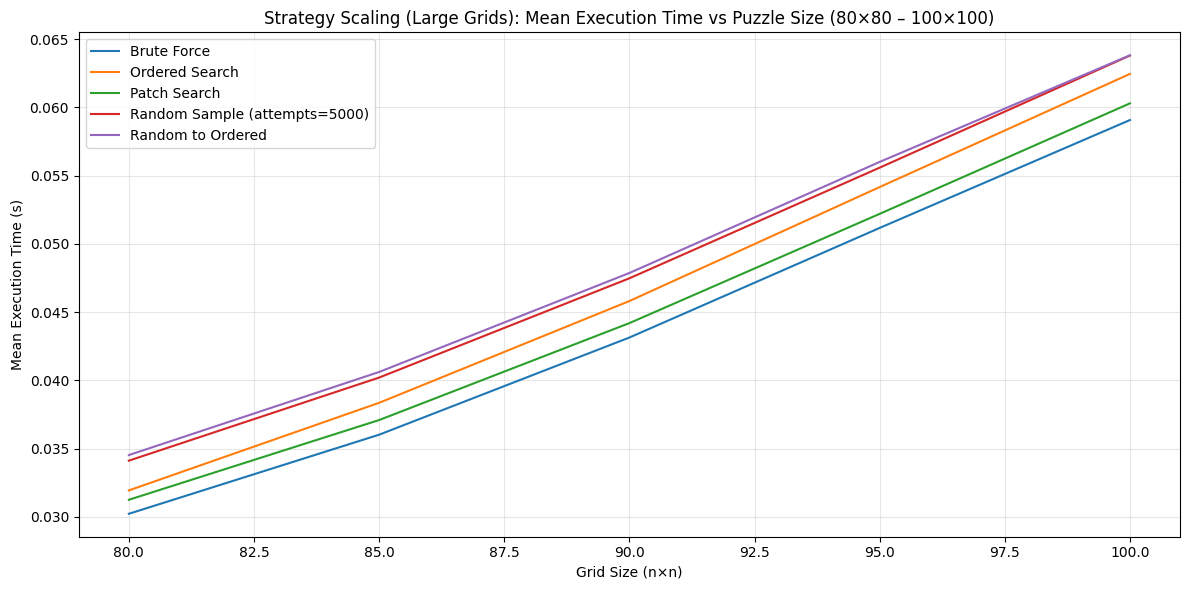

In [6]:
mean_time_zoom = mean_time[
    (mean_time['size'] >= 80) & 
    (mean_time['strategy'] != 'Uncommon Letter Search')
]

fig, ax = plt.subplots(figsize=(12, 6))

for strategy, group in mean_time_zoom.groupby('strategy'):
    ax.plot(group['size'], group['execution_time'], markersize=4, label=strategy)

ax.set_xlabel('Grid Size (n×n)')
ax.set_ylabel('Mean Execution Time (s)')
ax.set_title('Strategy Scaling (Large Grids): Mean Execution Time vs Puzzle Size (80×80 – 100×100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

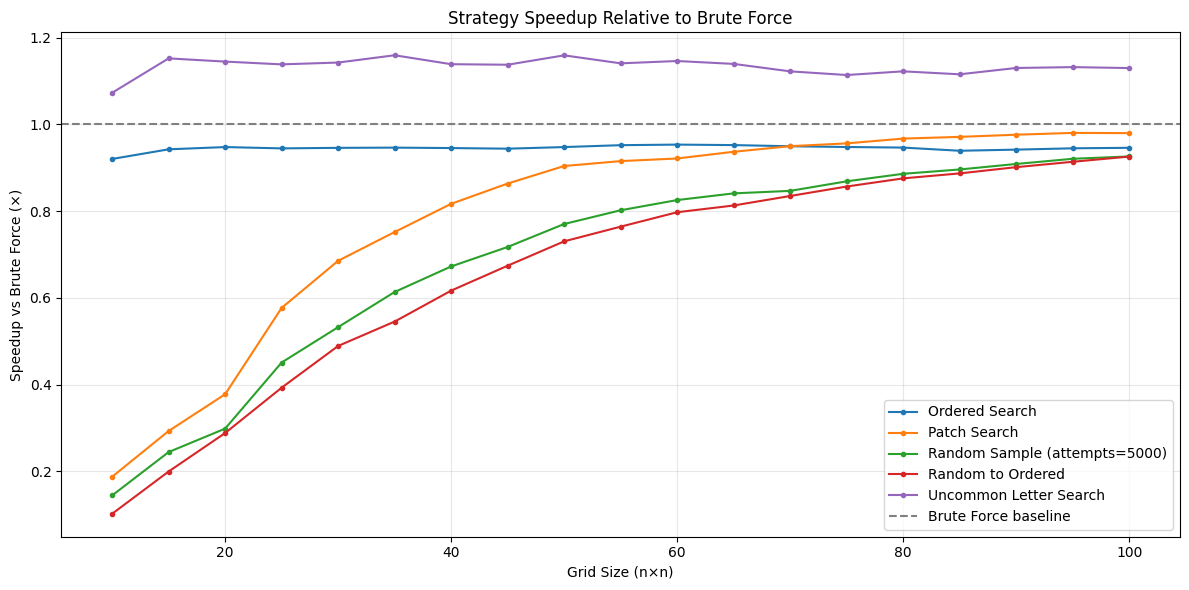

In [7]:
bf = mean_time[mean_time['strategy'] == 'Brute Force'][['size', 'execution_time']].rename(columns={'execution_time': 'bf_time'})
relative = mean_time.merge(bf, on='size')
relative['speedup'] = relative['bf_time'] / relative['execution_time']

fig, ax = plt.subplots(figsize=(12, 6))
for strategy, group in relative[relative['strategy'] != 'Brute Force'].groupby('strategy'):
    ax.plot(group['size'], group['speedup'], marker='o', markersize=3, label=strategy)
ax.axhline(1, color='gray', linestyle='--', label='Brute Force baseline')
ax.set_xlabel('Grid Size (n×n)')
ax.set_ylabel('Speedup vs Brute Force (×)')
ax.set_title('Strategy Speedup Relative to Brute Force')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## EFFICIENCY ANALYSIS

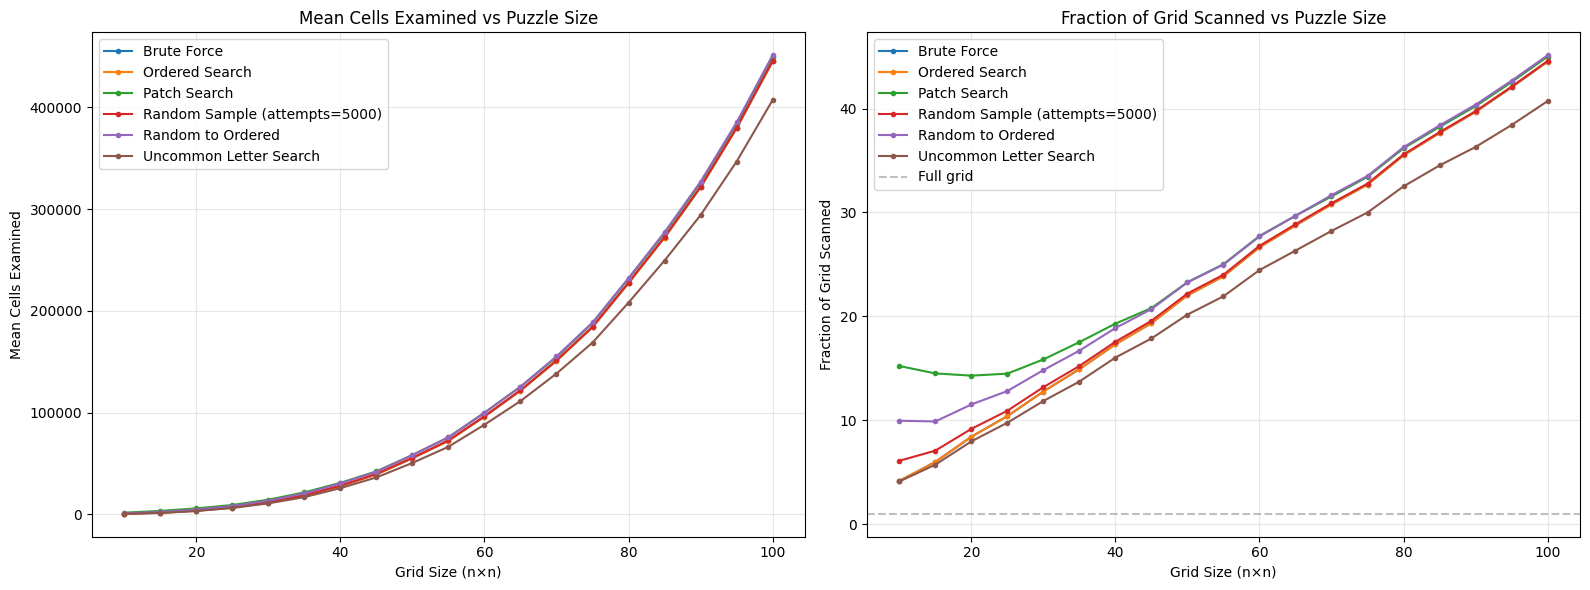

In [8]:
mean_cells = df.groupby(['strategy', 'size'])['cells_examined'].mean().reset_index()
mean_cells['grid_cells'] = mean_cells['size'] ** 2
mean_cells['fraction_scanned'] = mean_cells['cells_examined'] / mean_cells['grid_cells']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: raw cells examined
for strategy, group in mean_cells.groupby('strategy'):
    axes[0].plot(group['size'], group['cells_examined'], marker='o', markersize=3, label=strategy)
axes[0].set_xlabel('Grid Size (n×n)')
axes[0].set_ylabel('Mean Cells Examined')
axes[0].set_title('Mean Cells Examined vs Puzzle Size')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: fraction of grid scanned
for strategy, group in mean_cells.groupby('strategy'):
    axes[1].plot(group['size'], group['fraction_scanned'], marker='o', markersize=3, label=strategy)
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Full grid')
axes[1].set_xlabel('Grid Size (n×n)')
axes[1].set_ylabel('Fraction of Grid Scanned')
axes[1].set_title('Fraction of Grid Scanned vs Puzzle Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

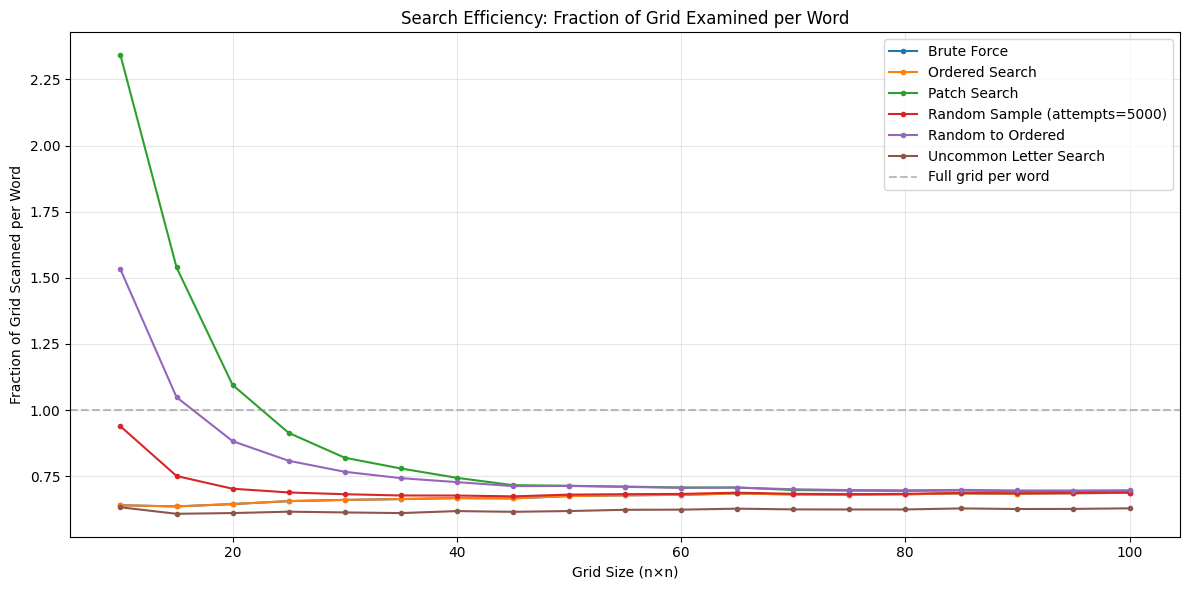

In [9]:
mean_efficiency = df.groupby(['strategy', 'size']).agg(
    cells_examined=('cells_examined', 'mean'),
    total_words=('total_words', 'mean')
).reset_index()

mean_efficiency['cells_per_word'] = mean_efficiency['cells_examined'] / mean_efficiency['total_words']
mean_efficiency['grid_cells'] = mean_efficiency['size'] ** 2
mean_efficiency['fraction_per_word'] = mean_efficiency['cells_per_word'] / mean_efficiency['grid_cells']

fig, ax = plt.subplots(figsize=(12, 6))
for strategy, group in mean_efficiency.groupby('strategy'):
    ax.plot(group['size'], group['fraction_per_word'], marker='o', markersize=3, label=strategy)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Full grid per word')
ax.set_xlabel('Grid Size (n×n)')
ax.set_ylabel('Fraction of Grid Scanned per Word')
ax.set_title('Search Efficiency: Fraction of Grid Examined per Word')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Formatted plots for report

In [10]:
# ── IEEE formatting ──────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'lines.linewidth':   1.8,
    'lines.markersize':  4,
    'axes.linewidth':    0.8,
    'grid.linewidth':    0.5,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    # 'text.usetex':     True,   # uncomment if LaTeX is installed
})

IEEE_1COL = 3.5    # single-column width (inches)
IEEE_2COL = 7.16   # full-width (both columns)

# Wong (2011) colorblind-safe palette
COLORS = {
    'Brute Force':                   '#000000',
    'Ordered Search':                '#0072B2',
    'Patch Search':                  '#009E73',
    'Random Sample (attempts=5000)': '#D55E00',
    'Random to Ordered':             '#CC79A7',
    'Uncommon Letter Search':        '#E69F00',
}
MARKERS = {
    'Brute Force':                   'o',
    'Ordered Search':                's',
    'Patch Search':                  '^',
    'Random Sample (attempts=5000)': 'D',
    'Random to Ordered':             'v',
    'Uncommon Letter Search':        '*',
}

os.makedirs('plots', exist_ok=True)

In [11]:
strategies_sorted = sorted(COLORS.keys())

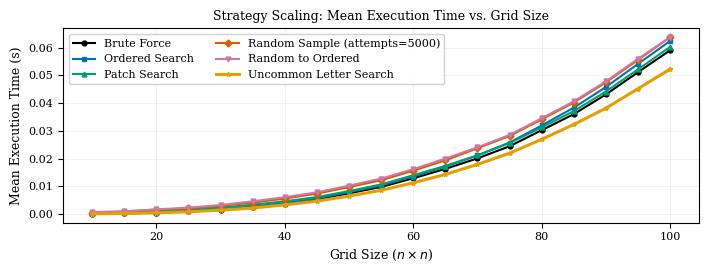

Saved fig1_time_scaling.pdf


In [12]:
# ── Figure 1: Mean execution time vs grid size (full width) ──────────────────
mean_time = df.groupby(['strategy', 'size'])['execution_time'].mean().reset_index()

fig, ax = plt.subplots(figsize=(IEEE_2COL, 2.8))
for strategy in strategies_sorted:
    group = mean_time[mean_time['strategy'] == strategy]
    lw = 2.2 if strategy == 'Uncommon Letter Search' else 1.5
    ax.plot(group['size'], group['execution_time'],
            color=COLORS[strategy], marker=MARKERS[strategy],
            linewidth=lw, markersize=3.5, label=strategy)

ax.set_xlabel('Grid Size ($n \\times n$)')
ax.set_ylabel('Mean Execution Time (s)')
ax.set_title('Strategy Scaling: Mean Execution Time vs. Grid Size')
ax.legend(ncol=2, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('../plots/fig1_time_scaling.pdf')
plt.show()
print("Saved fig1_time_scaling.pdf")

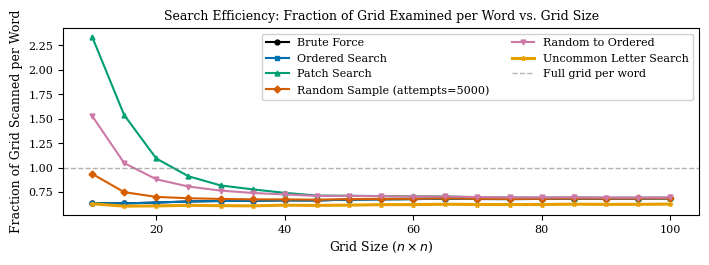

Saved fig2_efficiency.pdf


In [14]:
mean_eff = df.groupby(['strategy', 'size']).agg(
    cells_examined=('cells_examined', 'mean'),
    total_words=('total_words', 'mean')
).reset_index()
mean_eff['fraction_per_word'] = (mean_eff['cells_examined'] / mean_eff['total_words']) / (mean_eff['size'] ** 2)

fig, ax = plt.subplots(figsize=(IEEE_2COL, 2.8))
for strategy in strategies_sorted:
    group = mean_eff[mean_eff['strategy'] == strategy]
    lw = 2.2 if strategy == 'Uncommon Letter Search' else 1.5
    ax.plot(group['size'], group['fraction_per_word'],
            color=COLORS[strategy], marker=MARKERS[strategy],
            linewidth=lw, markersize=3.5, label=strategy)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.6, label='Full grid per word')
ax.set_xlabel('Grid Size ($n \\times n$)')
ax.set_ylabel('Fraction of Grid Scanned per Word')
ax.set_title('Search Efficiency: Fraction of Grid Examined per Word vs. Grid Size')
ax.legend(ncol=2, loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig('../plots/fig2_efficiency.pdf')
plt.show()
print("Saved fig2_efficiency.pdf")